### Import Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

os.makedirs("charts", exist_ok=True)

print("Libraries Imported Successfully")

Libraries Imported Successfully


### Load Cleaned Files

In [3]:
nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")

aum = pd.read_csv("../data/processed/03_aum_by_fund_house_clean.csv")

sip = pd.read_csv("../data/processed/04_monthly_sip_inflows_clean.csv")

category = pd.read_csv("../data/processed/05_category_inflows_clean.csv")

folio = pd.read_csv("../data/processed/06_industry_folio_count_clean.csv")

performance = pd.read_csv("../data/processed/07_scheme_performance_clean.csv")

investor = pd.read_csv("../data/processed/08_investor_transactions_clean.csv")

holdings = pd.read_csv("../data/processed/09_portfolio_holdings_clean.csv")

benchmark = pd.read_csv("../data/processed/10_benchmark_indices_clean.csv")

print("All cleaned datasets loaded successfully!")

All cleaned datasets loaded successfully!


### Dataset Overview

In [4]:
datasets = {
    "NAV": nav,
    "AUM": aum,
    "SIP": sip,
    "Category": category,
    "Folio": folio,
    "Investor": investor,
    "Holdings": holdings,
    "Benchmark": benchmark
}

for name, df in datasets.items():
    print("\n" + "="*50)
    print(name)
    print("Shape:", df.shape)
    print(df.head())


NAV
Shape: (46000, 3)
   amfi_code        date      nav
0     119551  2022-01-03  54.3856
1     119551  2022-01-04  54.3474
2     119551  2022-01-05  54.6869
3     119551  2022-01-06  55.4550
4     119551  2022-01-07  55.3692

AUM
Shape: (90, 5)
         date           fund_house  aum_lakh_crore  aum_crore  num_schemes
0  2022-03-31      SBI Mutual Fund            6.05     605000          186
1  2022-03-31  ICICI Prudential MF            4.65     465000          216
2  2022-03-31     HDFC Mutual Fund            4.35     435000          195
3  2022-03-31      Nippon India MF            2.70     270000          177
4  2022-03-31    Kotak Mahindra MF            2.70     270000          168

SIP
Shape: (48, 6)


     month  sip_inflow_crore  active_sip_accounts_crore  \
0  2022-01             11517                       4.91   
1  2022-02             11438                       4.93   
2  2022-03             12328                       5.09   
3  2022-04             11863                       5.48   
4  2022-05             12286                       5.55   

   new_sip_accounts_lakh  sip_aum_lakh_crore  yoy_growth_pct  
0                   9.10                4.80             NaN  
1                   8.20                4.85             NaN  
2                  10.50                5.01             NaN  
3                   9.52                5.12             NaN  
4                   8.10                5.15             NaN  

Category
Shape: (144, 3)
     month         category  net_inflow_crore
0  2024-04        Large Cap            2413.0
1  2024-04          Mid Cap            3897.0
2  2024-04        Small Cap            3533.0
3  2024-04        Flexi Cap            4947.0
4  2024-04 

### Missing Values Check

In [5]:
for name, df in datasets.items():
    print("\n" + name)
    print(df.isnull().sum())


NAV
amfi_code    0
date         0
nav          0
dtype: int64

AUM
date              0
fund_house        0
aum_lakh_crore    0
aum_crore         0
num_schemes       0
dtype: int64

SIP
month                         0
sip_inflow_crore              0
active_sip_accounts_crore     0
new_sip_accounts_lakh         0
sip_aum_lakh_crore            0
yoy_growth_pct               12
dtype: int64

Category
month               0
category            0
net_inflow_crore    0
dtype: int64

Folio
month                  0
total_folios_crore     0
equity_folios_crore    0
debt_folios_crore      0
hybrid_folios_crore    0
others_folios_crore    0
dtype: int64

Investor
investor_id           0
transaction_date      0
amfi_code             0
transaction_type      0
amount_inr            0
state                 0
city                  0
city_tier             0
age_group             0
gender                0
annual_income_lakh    0
payment_mode          0
kyc_status            0
dtype: int64

Holdings
amfi_

### AUM Growth By AMC

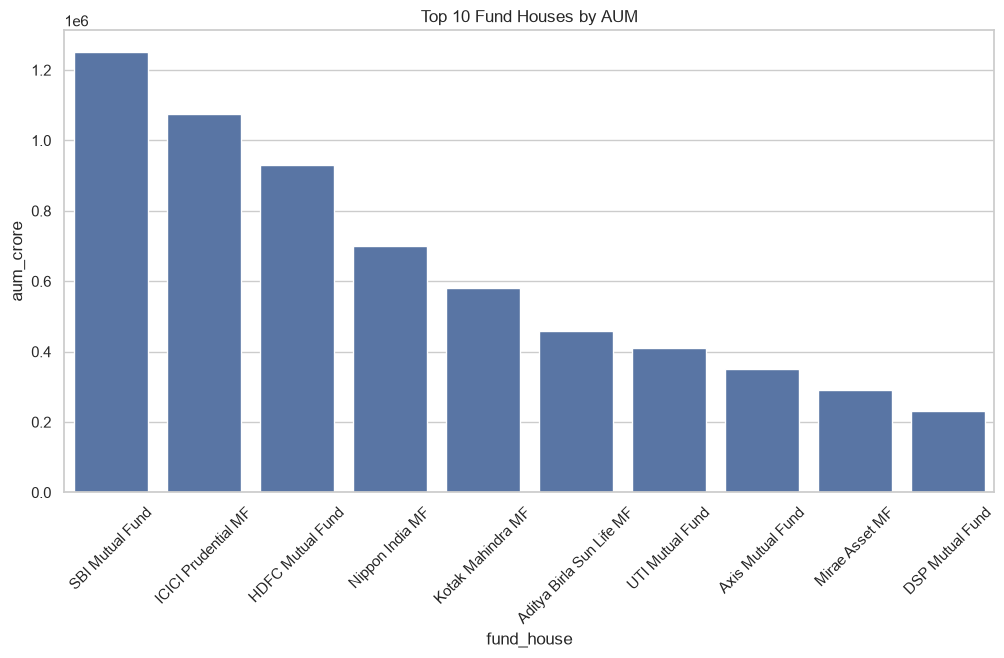

In [6]:
latest_aum = aum.sort_values('date').groupby('fund_house').last()

top10 = latest_aum.sort_values(
    'aum_crore',
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x='fund_house',
    y='aum_crore'
)

plt.xticks(rotation=45)

plt.title("Top 10 Fund Houses by AUM")

plt.savefig("../charts/aum_growth.png")
plt.show()

### Monthly SIP Trend

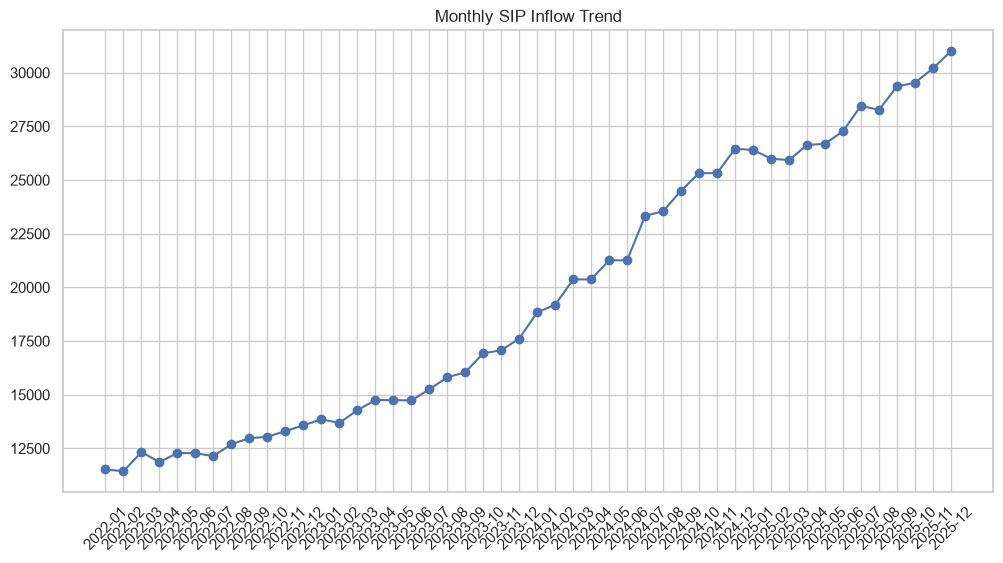

In [7]:
plt.figure(figsize=(12,6))

plt.plot(
    sip['month'],
    sip['sip_inflow_crore'],
    marker='o'
)

plt.xticks(rotation=45)

plt.title("Monthly SIP Inflow Trend")

plt.savefig("../charts/sip_trend.png")
plt.show()

### Category Heatmap

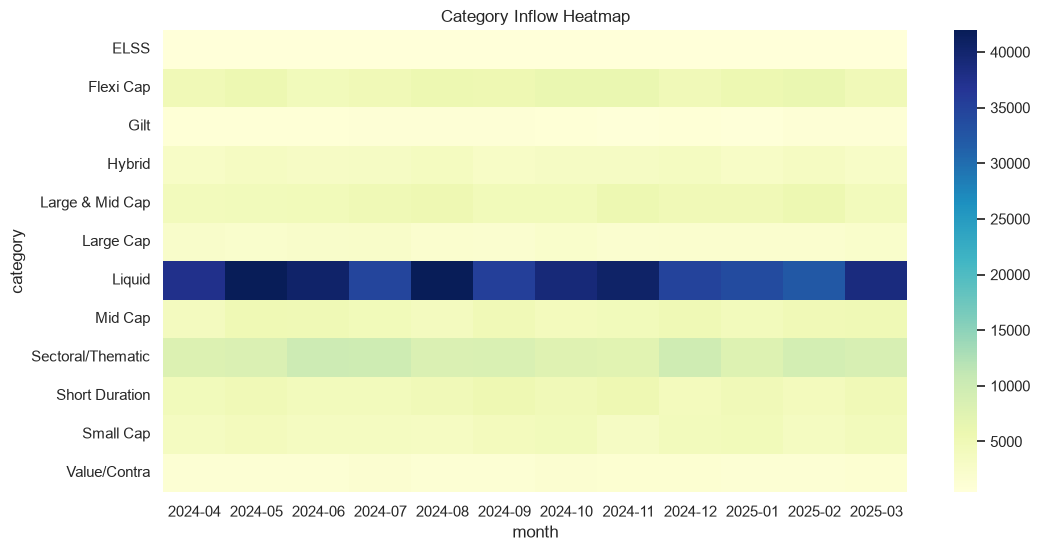

In [8]:
pivot = category.pivot(
    index='category',
    columns='month',
    values='net_inflow_crore'
)

plt.figure(figsize=(12,6))

sns.heatmap(
    pivot,
    cmap='YlGnBu'
)

plt.title("Category Inflow Heatmap")

plt.savefig("../charts/category_heatmap.png")
plt.show()

### Age Group Pie Chart

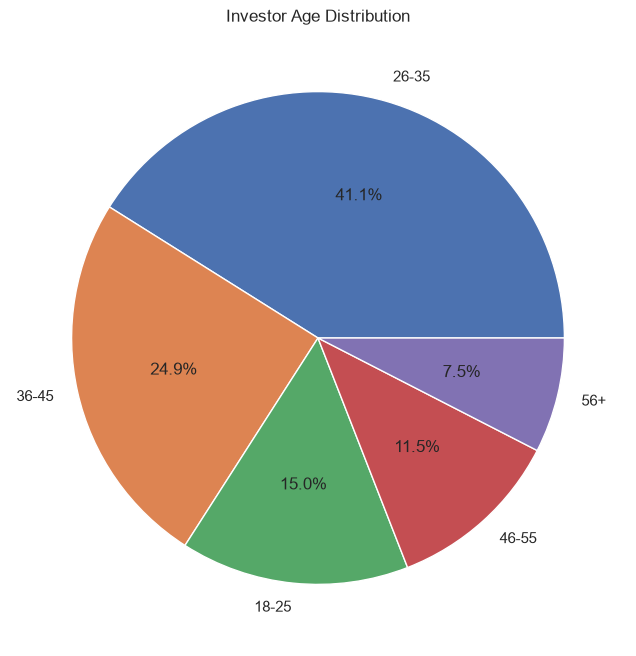

In [9]:
age = investor['age_group'].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    age.values,
    labels=age.index,
    autopct='%1.1f%%'
)

plt.title("Investor Age Distribution")

plt.savefig("../charts/age_distribution.png")
plt.show()

### SIP Amount Boxplot by Age

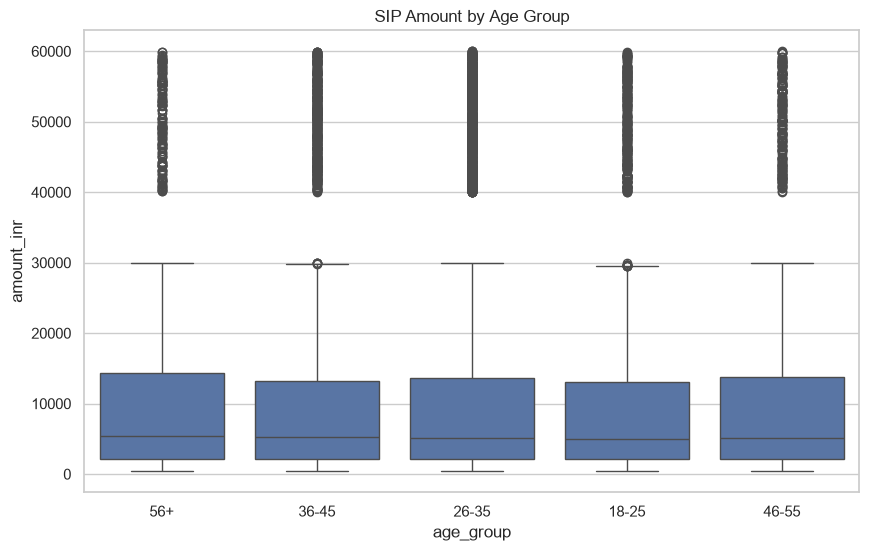

In [10]:
sip_age = investor[
    investor['transaction_type']=="SIP"
]

plt.figure(figsize=(10,6))

sns.boxplot(
    data=sip_age,
    x='age_group',
    y='amount_inr'
)

plt.title("SIP Amount by Age Group")

plt.savefig("../charts/sip_boxplot.png")
plt.show()

### State-wise Transaction Value

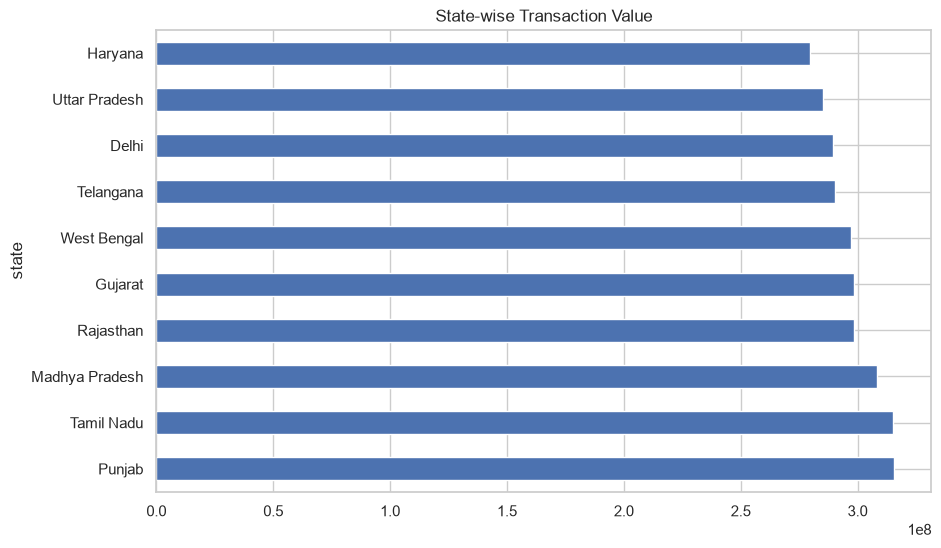

In [11]:
state = investor.groupby(
    'state'
)['amount_inr'].sum()

state = state.sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

state.plot(kind='barh')

plt.title("State-wise Transaction Value")

plt.savefig("../charts/state_transactions.png")
plt.show()

### T30 VS B30

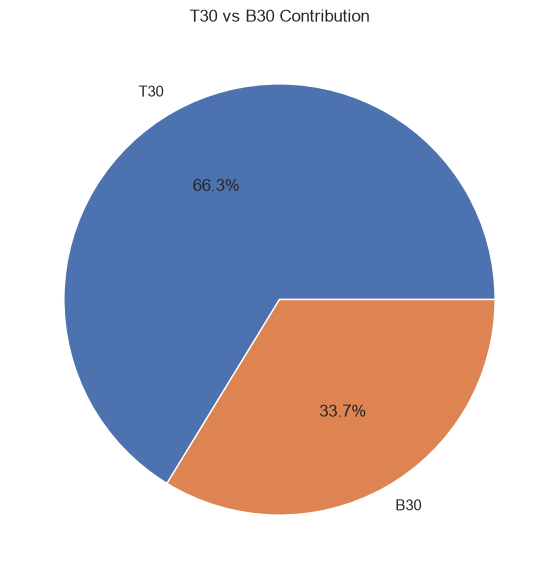

In [12]:
tier = investor['city_tier'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    tier.values,
    labels=tier.index,
    autopct='%1.1f%%'
)

plt.title("T30 vs B30 Contribution")

plt.savefig("../charts/t30_b30.png")
plt.show()

### Folio Growth

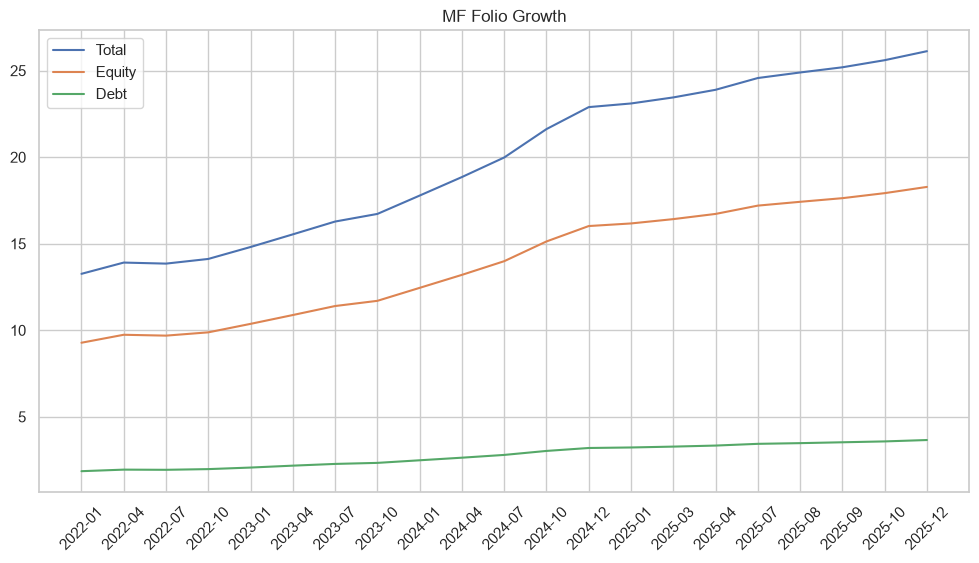

In [13]:
plt.figure(figsize=(12,6))

plt.plot(
    folio['month'],
    folio['total_folios_crore'],
    label='Total'
)

plt.plot(
    folio['month'],
    folio['equity_folios_crore'],
    label='Equity'
)

plt.plot(
    folio['month'],
    folio['debt_folios_crore'],
    label='Debt'
)

plt.legend()

plt.xticks(rotation=45)

plt.title("MF Folio Growth")

plt.savefig("../charts/folio_growth.png")
plt.show()

### Correlation Matrix

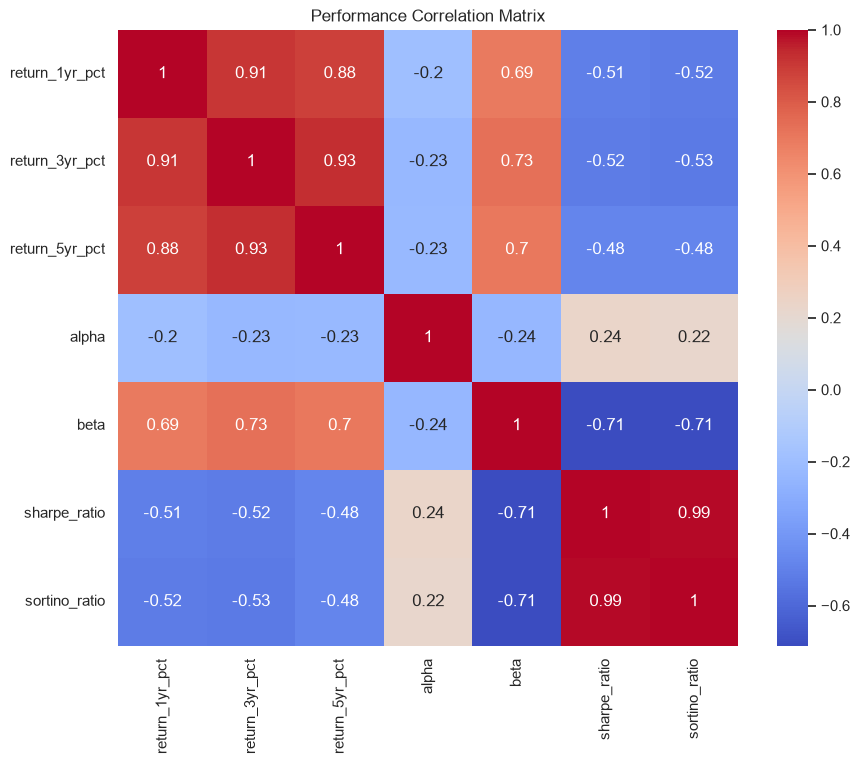

In [14]:
corr = performance[
    [
        'return_1yr_pct',
        'return_3yr_pct',
        'return_5yr_pct',
        'alpha',
        'beta',
        'sharpe_ratio',
        'sortino_ratio'
    ]
].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Performance Correlation Matrix")

plt.savefig("../charts/correlation_matrix.png")
plt.show()

### Sector Allocation Donut

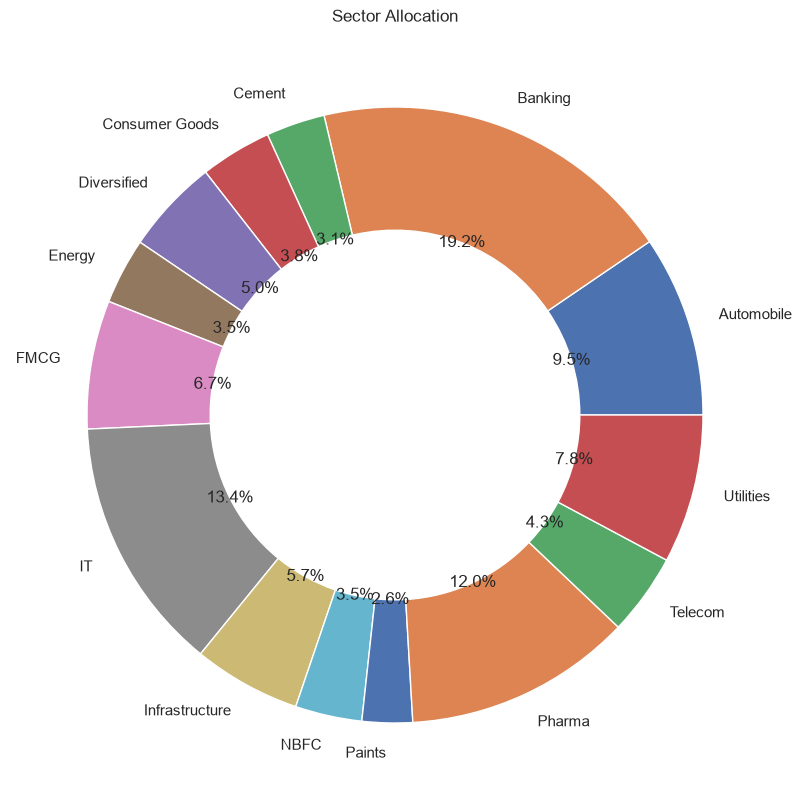

In [15]:
sector = holdings.groupby(
    'sector'
)['weight_pct'].sum()

plt.figure(figsize=(10,10))

plt.pie(
    sector.values,
    labels=sector.index,
    autopct='%1.1f%%',
    wedgeprops={'width':0.4}
)

plt.title("Sector Allocation")

plt.savefig("../charts/sector_allocation.png")
plt.show()

### Top Stocks by Weight

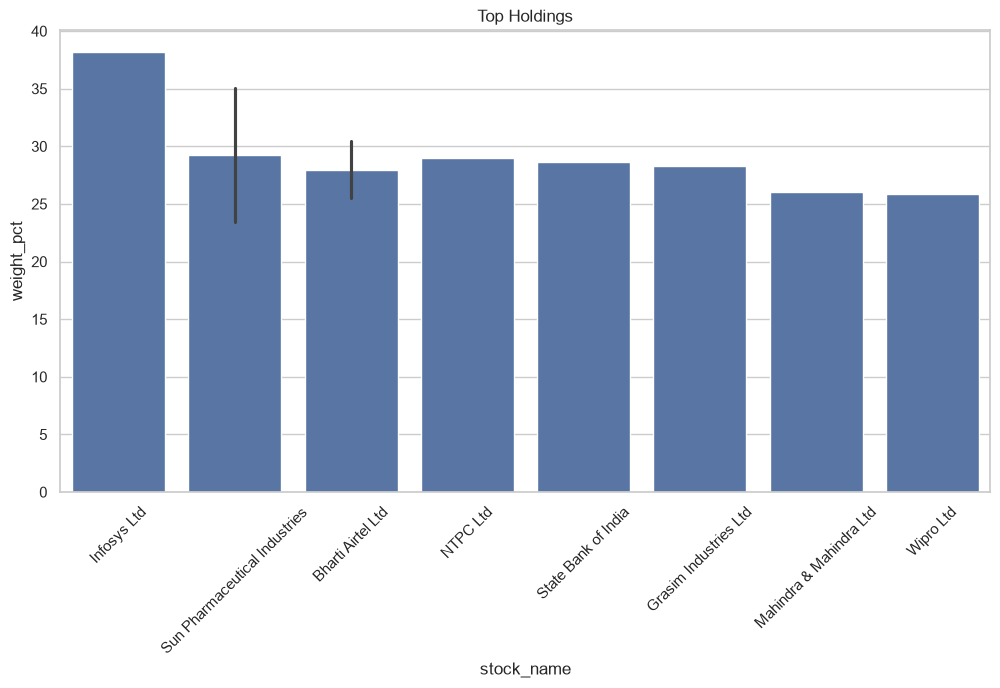

In [16]:
top = holdings.sort_values(
    'weight_pct',
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top,
    x='stock_name',
    y='weight_pct'
)

plt.xticks(rotation=45)

plt.title("Top Holdings")

plt.savefig("../charts/top_holdings.png")
plt.show()

### Sector Market Value

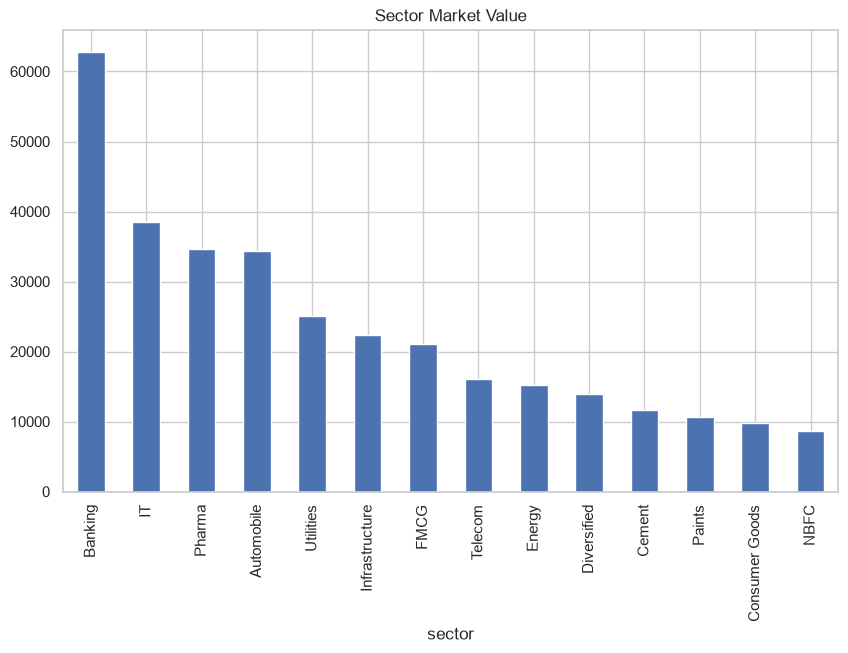

In [17]:
mv = holdings.groupby(
    'sector'
)['market_value_cr'].sum()

mv = mv.sort_values(
    ascending=False
)

plt.figure(figsize=(10,6))

mv.plot(kind='bar')

plt.title("Sector Market Value")

plt.savefig("../charts/sector_market_value.png")
plt.show()

### Stock Price Distribution

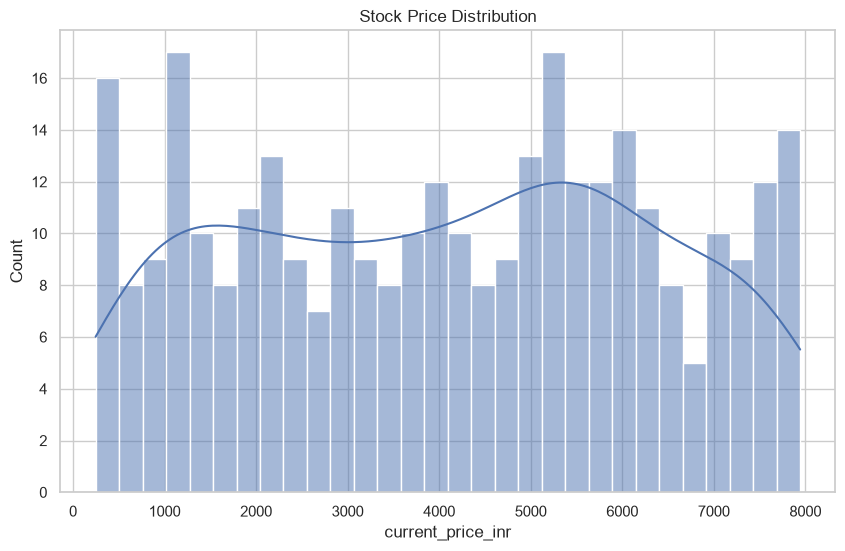

In [18]:
plt.figure(figsize=(10,6))

sns.histplot(
    holdings['current_price_inr'],
    bins=30,
    kde=True
)

plt.title("Stock Price Distribution")

plt.savefig("../charts/stock_price_dist.png")
plt.show()

### Risk vs Return Bubble Plot

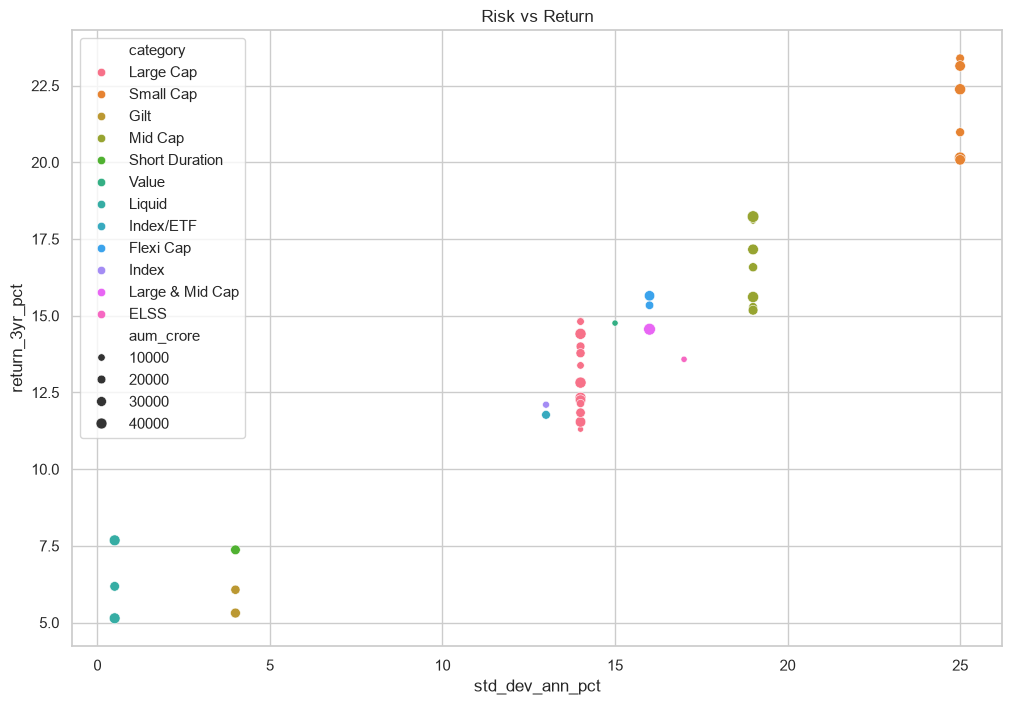

In [19]:
plt.figure(figsize=(12,8))

sns.scatterplot(
    data=performance,
    x='std_dev_ann_pct',
    y='return_3yr_pct',
    size='aum_crore',
    hue='category'
)

plt.title("Risk vs Return")

plt.savefig("../charts/risk_return.png")
plt.show()

### Benchmark Trend

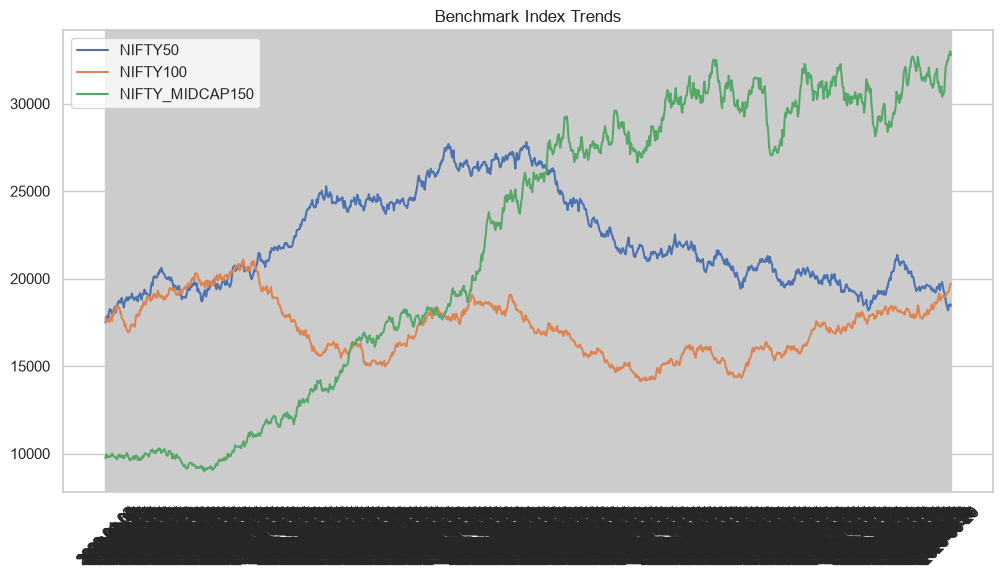

In [20]:
sample = benchmark[
    benchmark['index_name'].isin(
        benchmark['index_name'].unique()[:3]
    )
]

plt.figure(figsize=(12,6))

for idx in sample['index_name'].unique():

    temp = sample[
        sample['index_name']==idx
    ]

    plt.plot(
        temp['date'],
        temp['close_value'],
        label=idx
    )

plt.legend()

plt.xticks(rotation=45)

plt.title("Benchmark Index Trends")

plt.savefig("../charts/benchmark_trend.png")
plt.show()

### Gender Distribution

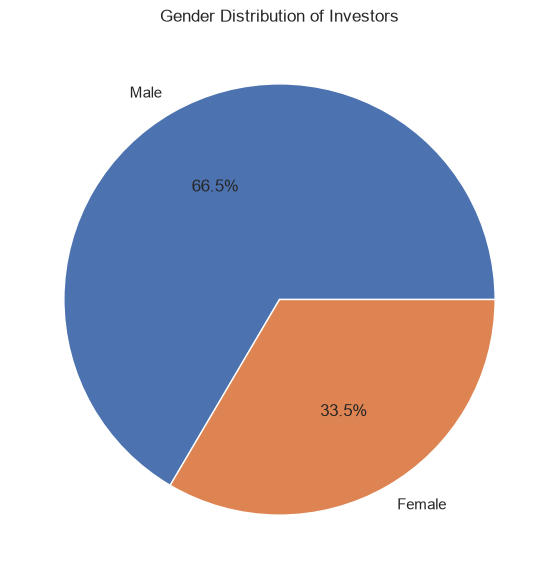

In [21]:
plt.figure(figsize=(7,7))

gender_counts = investor['gender'].value_counts()

plt.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct='%1.1f%%'
)

plt.title("Gender Distribution of Investors")

plt.savefig(
    "../charts/gender_distribution.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### NAV Trend with Bull Run

In [22]:
import plotly.express as px
import pandas as pd
import os

# Create charts folder if it doesn't exist
os.makedirs("../charts", exist_ok=True)

# Convert date column
nav['date'] = pd.to_datetime(nav['date'])

# Select all 40 schemes
sample_funds = nav['amfi_code'].unique()[:40]

nav_sample = nav[
    nav['amfi_code'].isin(sample_funds)
]

# Create interactive line chart
fig = px.line(
    nav_sample,
    x='date',
    y='nav',
    color='amfi_code',
    title='Daily NAV Trends (2022–2026) for 40 Mutual Fund Schemes',
    labels={
        'date': 'Date',
        'nav': 'NAV (₹)',
        'amfi_code': 'Scheme'
    }
)

# Highlight 2023 Bull Run
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.15,
    line_width=0,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

# Highlight 2024 Market Correction
fig.add_vrect(
    x0="2024-06-01",
    x1="2024-10-01",
    fillcolor="red",
    opacity=0.15,
    line_width=0,
    annotation_text="2024 Market Correction",
    annotation_position="top left"
)

# Improve layout
fig.update_layout(
    template="plotly_white",
    width=1400,
    height=800,
    legend_title="AMFI Code"
)

# Save as PNG
fig.write_image(
    "../charts/nav_trend.png",
    width=1400,
    height=800,
    scale=2
)

# Display chart
fig.show()

print("Chart saved as ../charts/nav_trend.png")

Chart saved as ../charts/nav_trend.png


### SIP Trend 2

In [23]:
import os
import plotly.express as px

# Create charts folder
os.makedirs("../charts", exist_ok=True)

# Convert month to datetime
sip['month'] = pd.to_datetime(sip['month'])

# Create Plotly line chart
fig = px.line(
    sip,
    x='month',
    y='sip_inflow_crore',
    title='Monthly SIP Inflows (2022–2025)',
    markers=True
)

# Annotate all-time high
fig.add_annotation(
    x='2025-12-01',
    y=31002,
    text='All-Time High: ₹31,002 Cr',
    showarrow=True,
    arrowhead=2,
    bgcolor='yellow'
)

# Improve layout
fig.update_layout(
    template='plotly_white',
    width=1200,
    height=600,
    xaxis_title='Month',
    yaxis_title='SIP Inflow (₹ Crore)'
)

# Save as PNG
fig.write_image(
    "../charts/sip_trend2.png",
    width=1200,
    height=600,
    scale=2
)

print("Chart saved successfully!")

# Show chart
fig.show()

Chart saved successfully!


### Key Findings

In [24]:
findings = """
#

1. Mutual fund folios nearly doubled from 13.26 Cr in January 2022 to 26.12 Cr in December 2025, indicating rapid growth in investor participation. (Refer: Folio Growth Chart)

2. Monthly SIP inflows showed a consistent upward trend, reaching an all-time high of ₹31,002 Cr in December 2025. (Refer: Monthly SIP Trend)

3. Investors aged 26–35 formed the largest segment, accounting for over 40 % of the total investor base. (Refer: Age Distribution Pie Chart)

4. T30 cities contributed approximately two-thirds of total investments, highlighting the dominance of urban participation in mutual funds. (Refer: T30 vs B30 Pie Chart)

5. Banking, IT, Pharma, and Automobile sectors represented the highest portfolio allocations across equity mutual funds. (Refer: Sector Allocation Donut Chart)

6. Small-cap and mid-cap funds delivered higher returns but exhibited significantly greater volatility compared to large-cap funds. (Refer: Risk vs Return Scatter Plot)

7. Equity folios expanded at a faster pace than debt folios, reflecting increasing investor preference for equity-based investments. (Refer: MF Folio Growth Chart)

8. Benchmark indices demonstrated strong long-term growth despite short-term market corrections, indicating positive market sentiment over the study period. (Refer: Benchmark Index Trends)

9. The correlation matrix revealed strong relationships among return metrics, while also indicating opportunities for portfolio diversification. (Refer: Performance Correlation Matrix)

10. Liquid funds consistently attracted the highest category-wise inflows, making them one of the most preferred investment options during the analysis period. (Refer: Category Inflow Heatmap)
"""

print(findings)


#

1. Mutual fund folios nearly doubled from 13.26 Cr in January 2022 to 26.12 Cr in December 2025, indicating rapid growth in investor participation. (Refer: Folio Growth Chart)

2. Monthly SIP inflows showed a consistent upward trend, reaching an all-time high of ₹31,002 Cr in December 2025. (Refer: Monthly SIP Trend)

3. Investors aged 26–35 formed the largest segment, accounting for over 40 % of the total investor base. (Refer: Age Distribution Pie Chart)

4. T30 cities contributed approximately two-thirds of total investments, highlighting the dominance of urban participation in mutual funds. (Refer: T30 vs B30 Pie Chart)

5. Banking, IT, Pharma, and Automobile sectors represented the highest portfolio allocations across equity mutual funds. (Refer: Sector Allocation Donut Chart)

6. Small-cap and mid-cap funds delivered higher returns but exhibited significantly greater volatility compared to large-cap funds. (Refer: Risk vs Return Scatter Plot)

7. Equity folios expanded at a f

### Conclusion

In [25]:
conclusion = """
The EDA reveals strong growth in India's mutual fund industry between 2022 and 2025.

Increasing SIP inflows, rising folio counts, and strong equity performance indicate growing investor confidence.

Risk and return analyses highlight the importance of diversification and category selection for long-term wealth creation.

Overall, the mutual fund ecosystem demonstrates healthy expansion and increasing market participation.
"""

print(conclusion)


The EDA reveals strong growth in India's mutual fund industry between 2022 and 2025.

Increasing SIP inflows, rising folio counts, and strong equity performance indicate growing investor confidence.

Risk and return analyses highlight the importance of diversification and category selection for long-term wealth creation.

Overall, the mutual fund ecosystem demonstrates healthy expansion and increasing market participation.

